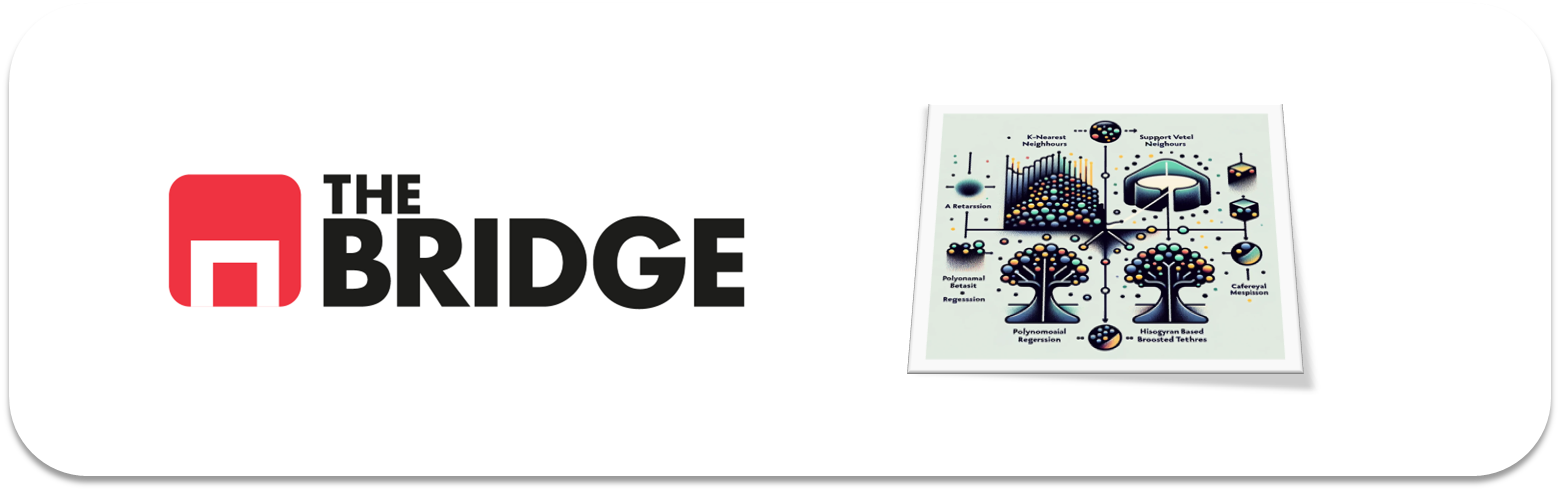

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulacion de datos
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Toolkit de visualizacion del bootcamp (esta en la misma carpeta)
import bootcampviztools as bvt

# Particionado, validacion y busqueda de hiperparametros
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de CLASIFICACION
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelos de REGRESION
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metricas
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             ConfusionMatrixDisplay,
                             mean_absolute_error, mean_absolute_percentage_error,
                             root_mean_squared_error, r2_score)

# El dataset tiene clases muy minoritarias (calidad 9 con muy pocos vinos), lo que
# genera muchos warnings en la validacion cruzada. Los silenciamos para que el
# notebook quede limpio.
import warnings
warnings.filterwarnings("ignore")

# Semilla para que los resultados sean reproducibles
RANDOM_STATE = 42

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
# OJO: el fichero usa el caracter "|" como separador de columnas
df = pd.read_csv("data/wines_dataset.csv", sep="|")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
# Informacion general: tipos de datos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [4]:
# Estadisticos descriptivos de las variables numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


**Primer vistazo:**

* El dataset tiene **6497 vinos** y **13 columnas**, sin valores nulos (como nos adelantaba el enunciado).
* 11 variables son fisicoquimicas y numericas (`float64`), `quality` es un entero (puntuacion de 3 a 9) y `class` es categorica (`white` / `red`).
* La unica variable que tendremos que **codificar** es `class`.

#### Definicion de los dos targets

* **Clasificacion:** predecir `quality` (la calidad/puntuacion del vino) a partir del resto de propiedades.
* **Regresion:** predecir `alcohol` (el grado alcoholico) a partir del resto de propiedades.

In [5]:
target_clf = "quality"   # CLASIFICACION: clases a predecir = puntuaciones 3..9
target_reg = "alcohol"   # REGRESION: valor continuo a predecir

print("Target de clasificacion:", target_clf)
print("Target de regresion    :", target_reg)

Target de clasificacion: quality
Target de regresion    : alcohol


#### Distribucion del target de clasificacion (`quality`)

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

En porcentaje:
quality
3     0.5
4     3.3
5    32.9
6    43.7
7    16.6
8     3.0
9     0.1
Name: proportion, dtype: float64


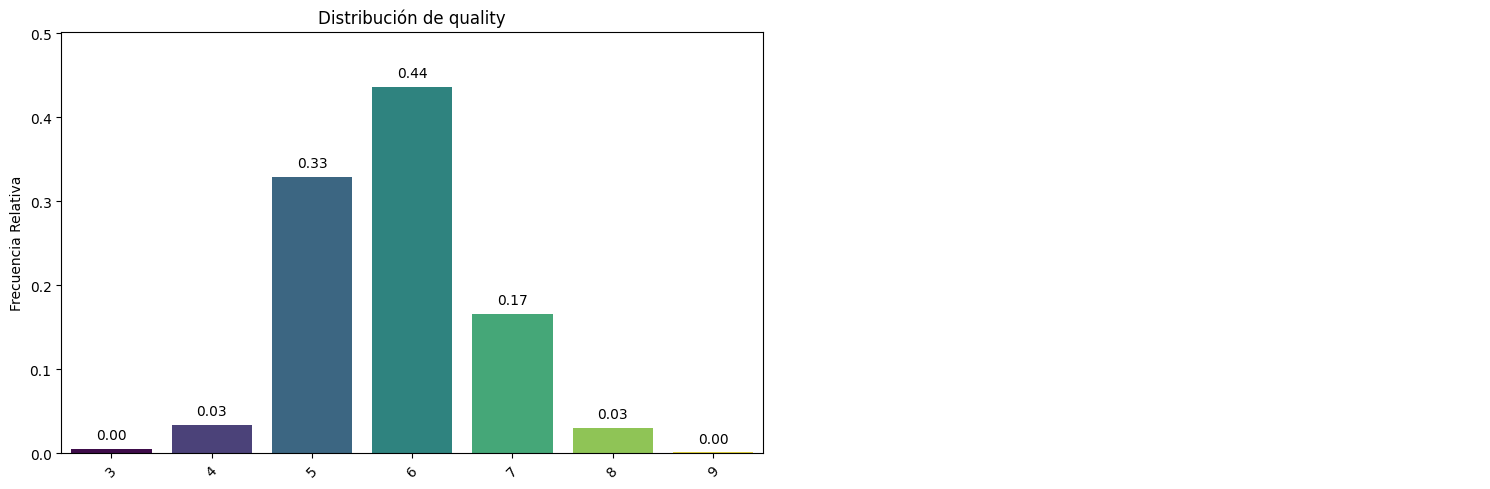

In [6]:
print(df[target_clf].value_counts().sort_index())
print()
print("En porcentaje:")
print((df[target_clf].value_counts(normalize=True).sort_index() * 100).round(1))

# Lo vemos graficamente con el toolkit del bootcamp
bvt.pinta_distribucion_categoricas(df, [target_clf], relativa=True, mostrar_valores=True)

#### Distribucion del target de regresion (`alcohol`)

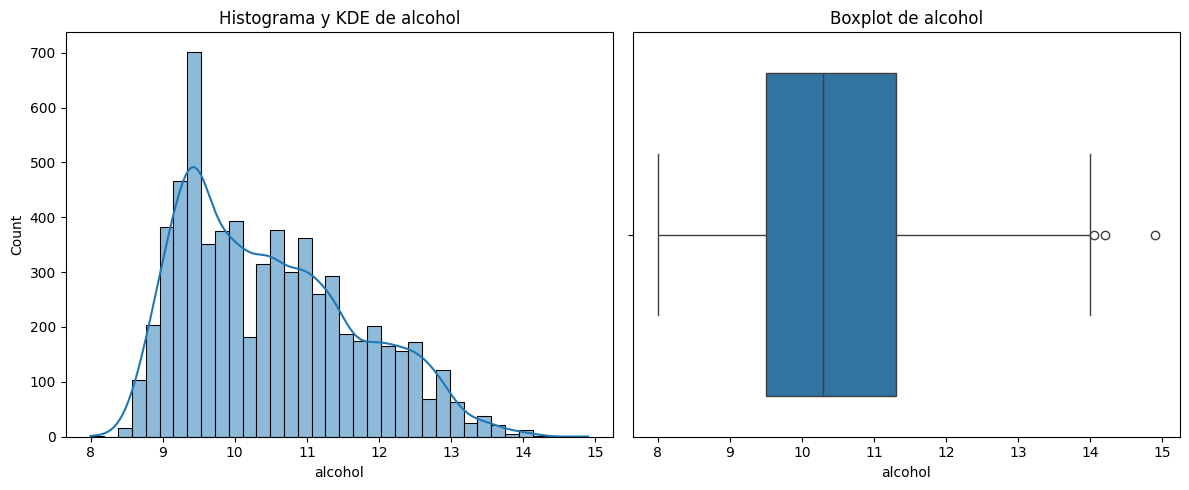

In [7]:
bvt.plot_combined_graphs(df, [target_reg])

#### Assessment previo de cada problema

**Clasificacion (`quality`)**
* Es un problema de **clasificacion multiclase** (puntuaciones de 3 a 9, 7 clases).
* Esta **muy desbalanceado**: las clases 5 y 6 acaparan ~77% de los vinos, mientras que la calidad 9 tiene solo 5 vinos y la 3 unos 30.
* El cliente quiere "clasificar correctamente lo mejor posible en media" -> nos pide el **mejor recall medio**. La metrica adecuada es la **balanced accuracy** (media de los recalls de todas las clases), que penaliza fallar en las clases minoritarias. Sera un problema dificil precisamente por ese desbalanceo.

**Regresion (`alcohol`)**
* `alcohol` es continua (entre 8 y ~15 grados), bastante simetrica.
* El cliente quiere "equivocarse lo menos posible **porcentualmente**" sobre el grado real -> la metrica natural es el **MAPE** (error porcentual absoluto medio). Tambien miraremos MAE/RMSE/R2 como apoyo.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

#### 2.1 Entendimiento del problema y metrica

Queremos **clasificar la calidad** del vino (clases 3..9) lo mejor posible "en media". Como el dataset esta muy desbalanceado, la metrica que mejor refleja ese objetivo es la **balanced accuracy** = media de los recalls por clase ("recall medio"). Sera nuestra metrica para comparar modelos (`scoring="balanced_accuracy"`).

#### 2.2 Preparacion: codificacion, features y split

Codificamos `class` (white/red -> 0/1). Para clasificar `quality` usamos como features **todas** las demas columnas (incluida `alcohol`). Hacemos un split **estratificado** para mantener la proporcion de clases en train y test (clave con el desbalanceo).

In [8]:
# Codificamos la unica categorica. Reutilizaremos df_model tambien en la regresion.
df_model = df.copy()
df_model["class"] = df_model["class"].map({"white": 0, "red": 1})

# Features = todo menos el target de clasificacion
X = df_model.drop(columns=[target_clf])
y = df_model[target_clf]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5197, 12) | Test: (1300, 12)


#### 2.3 MiniEDA: target en train y analisis bivariante

Comprobamos que el desbalanceo se mantiene en train y miramos como se distribuyen algunas features segun la calidad (usando el toolkit del bootcamp).

In [9]:
print("Distribucion del target en TRAIN (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1))

Distribucion del target en TRAIN (%):
quality
3     0.5
4     3.3
5    32.9
6    43.7
7    16.6
8     3.0
9     0.1
Name: proportion, dtype: float64


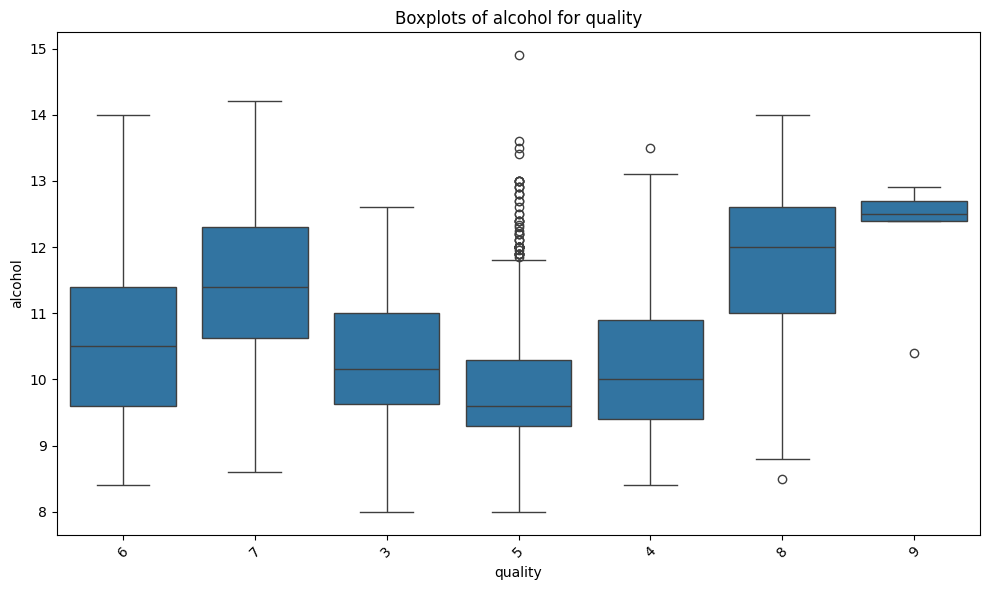

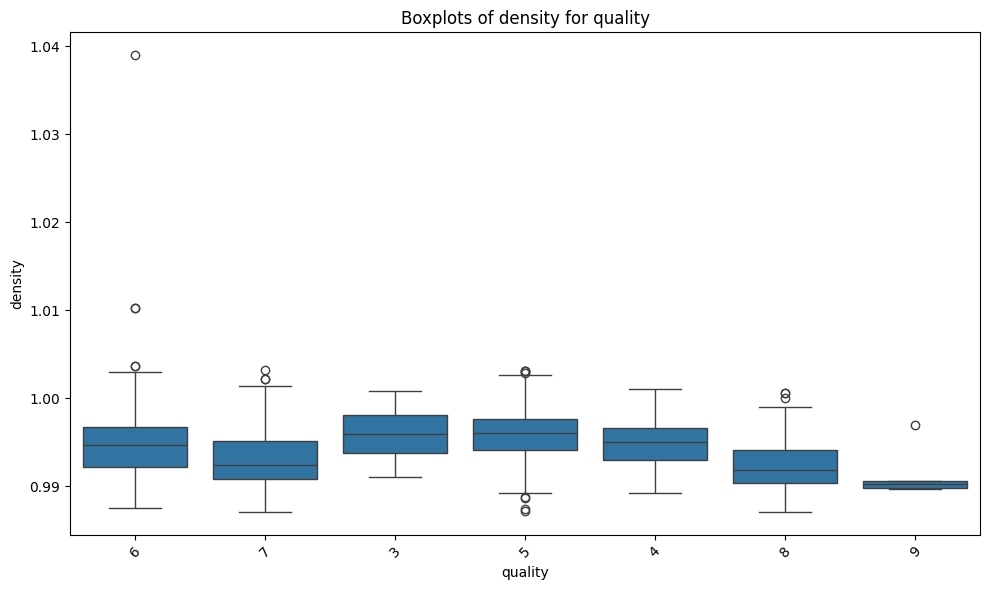

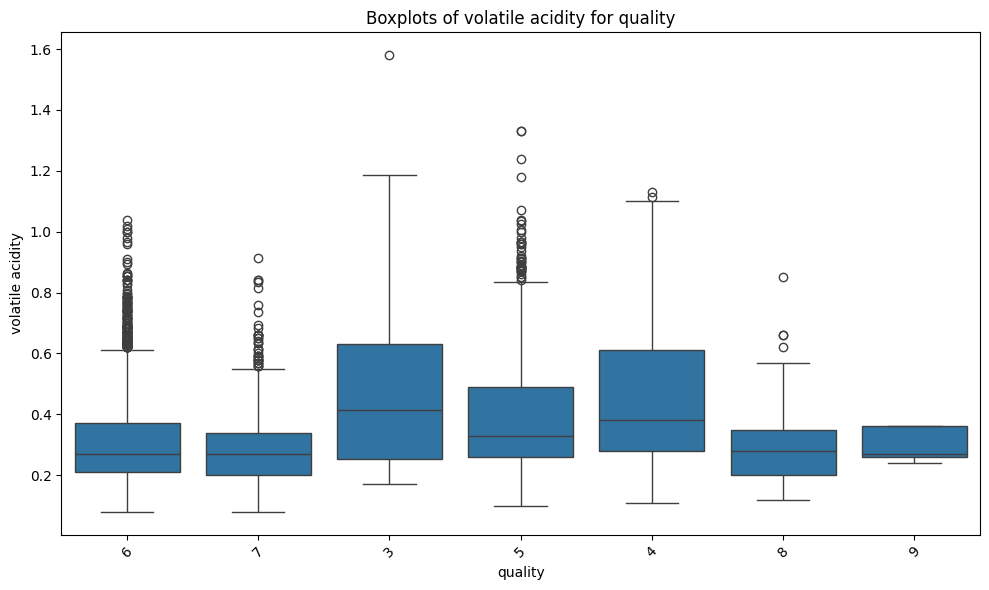

In [10]:
# Boxplots de algunas features clave segun la calidad.
# (alcohol y density son las mas correlacionadas con quality)
for feature in ["alcohol", "density", "volatile acidity"]:
    bvt.plot_grouped_boxplots(df, cat_col="quality", num_col=feature, size_group=7)

Se aprecia una tendencia clara: **a mayor alcohol y menor densidad/acidez volatil, mejor calidad**, pero las cajas se solapan mucho entre clases vecinas (un 5 y un 6 se parecen). Esto adelanta que sera dificil separar clases contiguas.

#### 2.4 Tratamiento de features e instanciacion de modelos (baseline)

Algunos modelos (KNN, regresion logistica) necesitan que las features esten **escaladas** para que no dominen las de mayor rango. Para evitar *fuga de datos* en la validacion cruzada, metemos el `StandardScaler` dentro de un **`Pipeline`** junto a cada modelo (asi el escalado se ajusta solo con el train de cada fold). A los modelos de arbol el escalado no les afecta, pero no les perjudica.

Usaremos un **KNN como baseline** (con 2 valores de K) y, ademas, regresion logistica, arbol de decision y random forest.

In [11]:
modelos_clf = {
    "KNN (k=5)":     Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]),
    "KNN (k=15)":    Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=15))]),
    "LogReg":        Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "Arbol":         Pipeline([("scaler", StandardScaler()), ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("scaler", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))]),
}

#### 2.5 Comparativa con validacion cruzada (k=5)

In [12]:
print("Comparativa por validacion cruzada (balanced_accuracy, mayor = mejor):\n")
for nombre, modelo in modelos_clf.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy")
    print(f"{nombre:14s}  {scores.mean():.3f} +/- {scores.std():.3f}")

Comparativa por validacion cruzada (balanced_accuracy, mayor = mejor):



KNN (k=5)       0.281 +/- 0.035


KNN (k=15)      0.244 +/- 0.012


LogReg          0.235 +/- 0.017
Arbol           0.266 +/- 0.016


Random Forest   0.365 +/- 0.035


El **Random Forest** suele ganar con bastante diferencia. El KNN (baseline) y la regresion logistica se quedan claramente por detras en recall medio. Elegimos el **Random Forest** como modelo a optimizar.

#### 2.6 Optimizacion de hiperparametros del modelo elegido

Hacemos un `GridSearchCV` sobre el Random Forest. **Incluimos `class_weight`** en el grid: es el hiperparametro que permite al modelo *compensar el desbalanceo* dando mas peso a las clases minoritarias (justo lo que mejora el recall medio).

In [13]:
pipe_rf = Pipeline([("scaler", StandardScaler()),
                    ("model", RandomForestClassifier(random_state=RANDOM_STATE))])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 3],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}

grid_clf = GridSearchCV(pipe_rf, param_grid, cv=5,
                        scoring="balanced_accuracy", n_jobs=-1)
grid_clf.fit(X_train, y_train)

print("Mejores parametros:", grid_clf.best_params_)
print("Mejor balanced_accuracy (CV):", round(grid_clf.best_score_, 3))

Mejores parametros: {'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Mejor balanced_accuracy (CV): 0.396


#### 2.7 Evaluacion contra test

In [14]:
mejor_clf = grid_clf.best_estimator_
y_pred = mejor_clf.predict(X_test)

print("Balanced accuracy (test):", round(balanced_accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, zero_division=0))

Balanced accuracy (test): 0.381

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.56      0.23      0.33        43
           5       0.71      0.74      0.72       428
           6       0.67      0.70      0.69       567
           7       0.60      0.64      0.62       216
           8       0.64      0.36      0.46        39
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1300
   macro avg       0.45      0.38      0.40      1300
weighted avg       0.67      0.67      0.67      1300



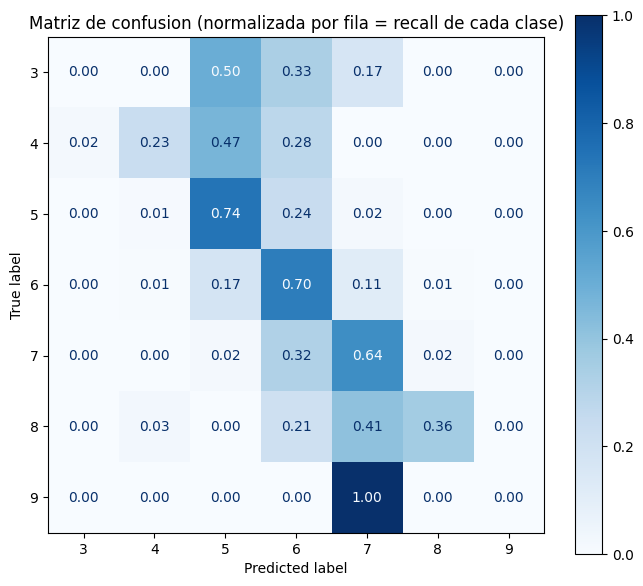

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize="true", cmap="Blues", values_format=".2f", ax=ax
)
plt.title("Matriz de confusion (normalizada por fila = recall de cada clase)")
plt.show()

#### 2.8 Analisis de errores y mecanismos de mejora

* El modelo acierta razonablemente bien en las clases mayoritarias (5, 6 y 7), pero **falla en las clases extremas** (3, 4, 8 y 9), que tienen muy pocos ejemplos: la matriz de confusion muestra que casi todos sus errores caen en la **clase vecina** (un vino de calidad 4 se predice como 5, etc.).
* Esto es coherente con el EDA: las clases contiguas se solapan mucho en sus propiedades.
* El `class_weight="balanced"` ayuda a subir algo el recall medio, pero hay un techo claro por la falta de datos en los extremos.

**Posibles mejoras (esbozo):**
1. **Reagrupar la calidad** en pocas categorias (p. ej. *baja* / *media* / *alta*) si el negocio lo permite: el problema se vuelve mucho mas tratable.
2. **Conseguir mas muestras** de las clases minoritarias (3, 4, 8, 9) o aplicar **remuestreo** (p. ej. SMOTE) sobre el train.
3. Probar modelos de **boosting** (GradientBoosting / XGBoost), que suelen rendir algo mejor.
4. Afinar mas el `class_weight` (pesos manuales) o el umbral por clase.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

#### 3.1 Entendimiento del problema y metrica

Queremos predecir el **grado alcoholico** (`alcohol`). El cliente quiere equivocarse lo menos posible **en porcentaje** sobre el valor real -> metrica principal **MAPE** (`mean_absolute_percentage_error`). Recordatorio: en sklearn las metricas de error se pasan como `neg_...` (mayor = mejor), por eso usaremos `scoring="neg_mean_absolute_percentage_error"`.

#### 3.2 Preparacion y split

Reutilizamos `df_model` (con `class` ya codificada). Ahora el target es `alcohol` y las features son el resto de columnas; **`quality` SI entra como feature** (el enunciado pide usar "su clase y la puntuacion de calidad"). Como es regresion, el split no necesita estratificar.

In [16]:
X_r = df_model.drop(columns=[target_reg])
y_r = df_model[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train_r.shape, "| Test:", X_test_r.shape)

Train: (5197, 12) | Test: (1300, 12)


#### 3.3 MiniEDA: correlaciones con el target

density                -0.686745
residual sugar         -0.359415
total sulfur dioxide   -0.265740
chlorides              -0.256916
free sulfur dioxide    -0.179838
fixed acidity          -0.095452
volatile acidity       -0.037640
class                  -0.032970
citric acid            -0.010493
sulphates              -0.003029
pH                      0.121248
quality                 0.444319
alcohol                 1.000000
Name: alcohol, dtype: float64


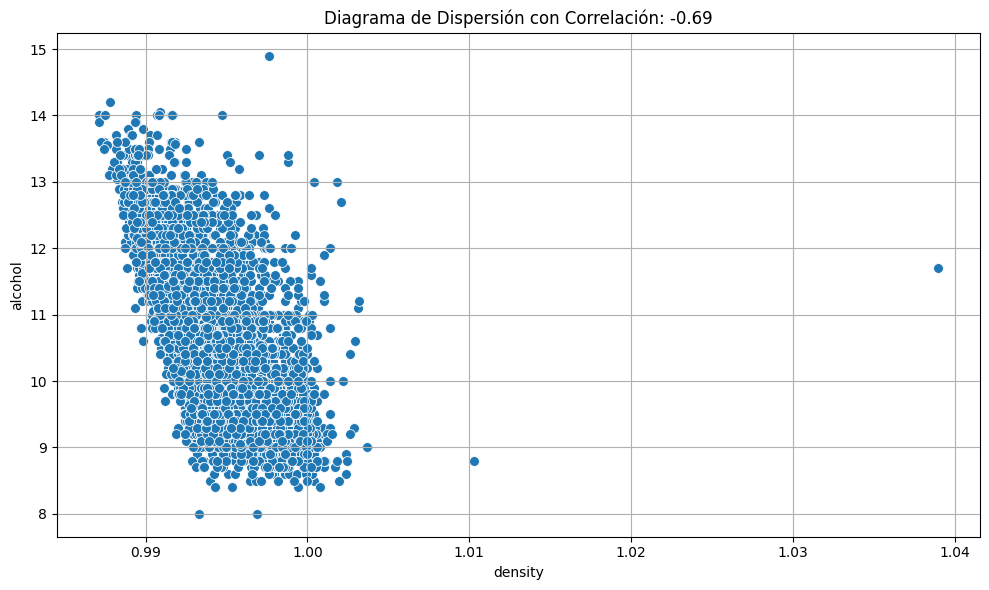

In [17]:
# Correlacion de cada feature con el grado alcoholico
print(df_model.corr(numeric_only=True)[target_reg].sort_values())

# La mas correlacionada (negativa) es la densidad: la vemos con el toolkit
bvt.grafico_dispersion_con_correlacion(df, "density", "alcohol", mostrar_correlacion=True)

La **densidad** es la variable mas relacionada con el alcohol (correlacion ~ -0.69): a mas alcohol, menos densidad (el alcohol es menos denso que el agua). Tambien ayudan `quality`, `residual sugar` y los sulfuros. Esto hace pensar que la regresion sera bastante precisa.

#### 3.4 Instanciacion de modelos y comparativa con validacion cruzada

Comparamos cuatro modelos (regresion lineal como baseline, KNN, arbol y random forest), de nuevo con escalado dentro de un Pipeline.

In [18]:
modelos_reg = {
    "Regresion Lineal": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "KNN Regresor":     Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=10))]),
    "Arbol":            Pipeline([("scaler", StandardScaler()), ("model", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))]),
    "Random Forest":    Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE))]),
}

print("Comparativa por validacion cruzada (MAPE, menor = mejor):\n")
for nombre, modelo in modelos_reg.items():
    scores = cross_val_score(modelo, X_train_r, y_train_r, cv=5,
                             scoring="neg_mean_absolute_percentage_error")
    print(f"{nombre:18s}  MAPE = {-scores.mean()*100:.2f}%  (+/- {scores.std()*100:.2f})")

Comparativa por validacion cruzada (MAPE, menor = mejor):



Regresion Lineal    MAPE = 3.37%  (+/- 0.07)


KNN Regresor        MAPE = 4.31%  (+/- 0.15)
Arbol               MAPE = 4.09%  (+/- 0.08)


Random Forest       MAPE = 2.67%  (+/- 0.11)


El **Random Forest** vuelve a ser el mejor (menor MAPE). Lo elegimos para optimizar sus hiperparametros.

#### 3.5 Optimizacion de hiperparametros del modelo elegido

In [19]:
pipe_rf_r = Pipeline([("scaler", StandardScaler()),
                      ("model", RandomForestRegressor(random_state=RANDOM_STATE))])

param_grid_r = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2],
}

grid_reg = GridSearchCV(pipe_rf_r, param_grid_r, cv=5,
                        scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
grid_reg.fit(X_train_r, y_train_r)

print("Mejores parametros:", grid_reg.best_params_)
print("Mejor MAPE (CV):", round(-grid_reg.best_score_ * 100, 2), "%")

Mejores parametros: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Mejor MAPE (CV): 2.67 %


#### 3.6 Evaluacion contra test

In [20]:
mejor_reg = grid_reg.best_estimator_
y_pred_r = mejor_reg.predict(X_test_r)

mape = mean_absolute_percentage_error(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = root_mean_squared_error(y_test_r, y_pred_r)
r2   = r2_score(y_test_r, y_pred_r)

print(f"MAPE : {mape*100:.2f} %   <- metrica de negocio")
print(f"MAE  : {mae:.3f} grados")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")

MAPE : 2.48 %   <- metrica de negocio
MAE  : 0.262 grados
RMSE : 0.401
R2   : 0.886


#### 3.7 Analisis de errores

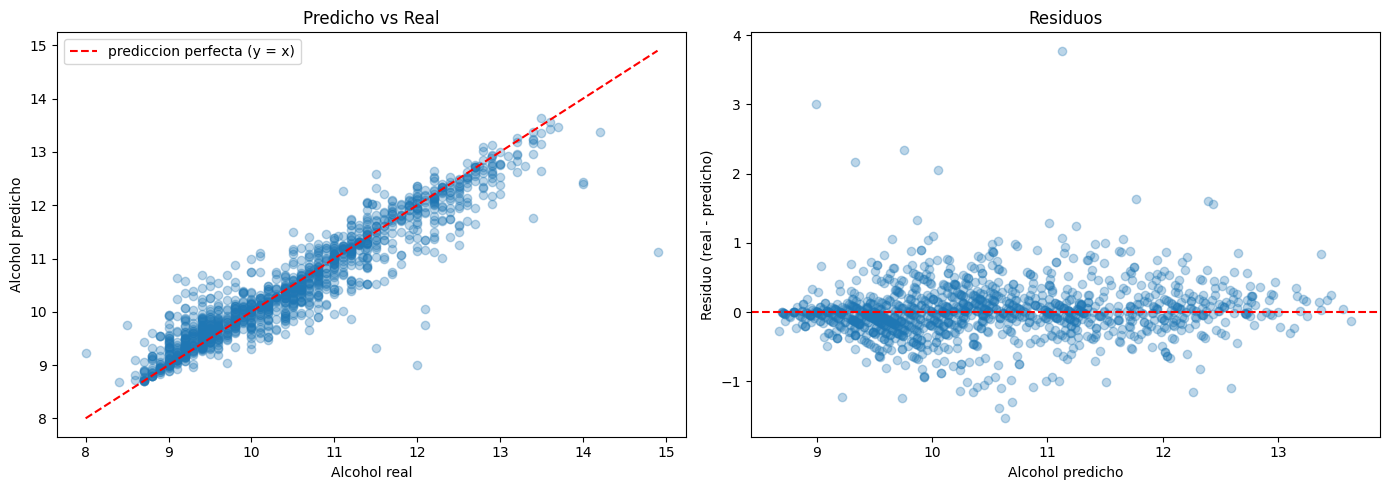

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Predicho vs real -> cuanto mas pegado a la diagonal, mejor
axes[0].scatter(y_test_r, y_pred_r, alpha=0.3)
lims = [y_test_r.min(), y_test_r.max()]
axes[0].plot(lims, lims, "r--", label="prediccion perfecta (y = x)")
axes[0].set_xlabel("Alcohol real")
axes[0].set_ylabel("Alcohol predicho")
axes[0].set_title("Predicho vs Real")
axes[0].legend()

# (2) Residuos -> deberian repartirse en torno a 0 sin patron
residuos = y_test_r - y_pred_r
axes[1].scatter(y_pred_r, residuos, alpha=0.3)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Alcohol predicho")
axes[1].set_ylabel("Residuo (real - predicho)")
axes[1].set_title("Residuos")

plt.tight_layout()
plt.show()

#### Conclusion del problema de regresion

* El modelo predice el grado alcoholico con un **MAPE de ~2.5%**, muy por debajo de cualquier umbral razonable: cumple de sobra el objetivo de negocio (equivocarse poco porcentualmente).
* En el grafico *predicho vs real* los puntos se pegan a la diagonal y los **residuos se reparten en torno a 0** sin un patron claro.
* Los **mayores errores** aparecen en los vinos con alcohol extremo (colas de la distribucion), donde hay menos ejemplos. La densidad es, con diferencia, la variable mas informativa.
* Mejora posible: anadir interacciones o probar boosting, aunque con este MAPE el margen de mejora es pequeno.